In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/linear_regression_dataset.csv')
df

,Feature1,Feature2,Feature3,Category,Name,Target
0,54.967142,72.642384,62,A,Alice,371.099650
1,48.617357,64.446117,63,B,Charlie,299.184743
2,56.476885,61.820944,25,C,Bob,319.605931
3,65.230299,62.149045,56,C,Alice,348.440917
4,47.658466,41.569469,33,C,Bob,201.644393
...,...,...,...,...,...,...
200,54.967142,72.642384,62,A,Alice,371.099650
201,48.617357,64.446117,63,B,Charlie,299.184743
202,56.476885,61.820944,25,C,Bob,319.605931
203,65.230299,62.149045,56,C,Alice,348.440917


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  195 non-null    float64
 1   Feature2  197 non-null    float64
 2   Feature3  205 non-null    int64  
 3   Category  205 non-null    object 
 4   Name      205 non-null    object 
 5   Target    205 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 9.7+ KB


In [ ]:
df.isnull().sum()

,0
Feature1,10
Feature2,8
Feature3,0
Category,0
Name,0
Target,0


In [ ]:
for col in df.columns:
    if(df[col].dtype=='object'):
      df[col]=df[col].fillna(df[col].mode())
    else:
      df[col]=df[col].fillna(df[col].mean())

In [ ]:
df.isnull().sum()

,0
Feature1,0
Feature2,0
Feature3,0
Category,0
Name,0
Target,0


In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df.drop_duplicates(inplace=True)

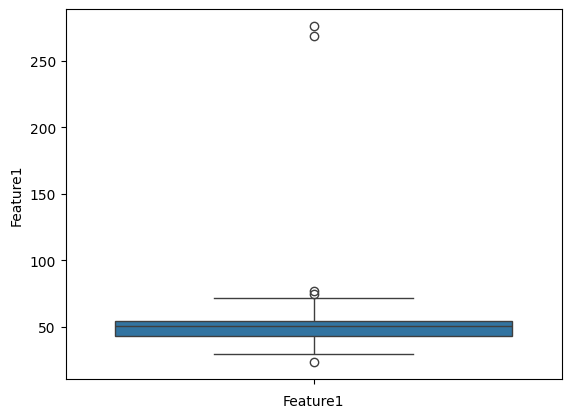

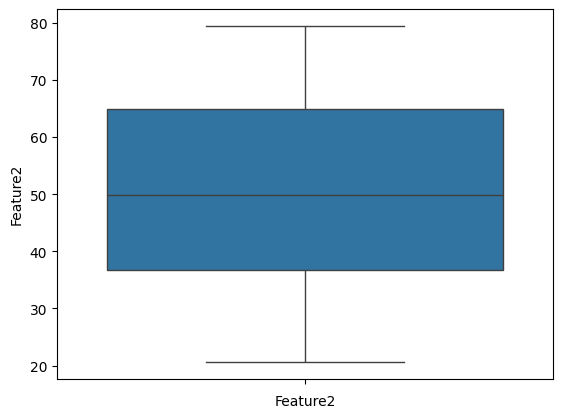

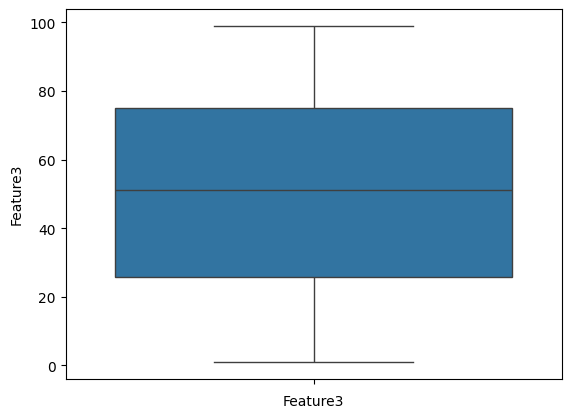

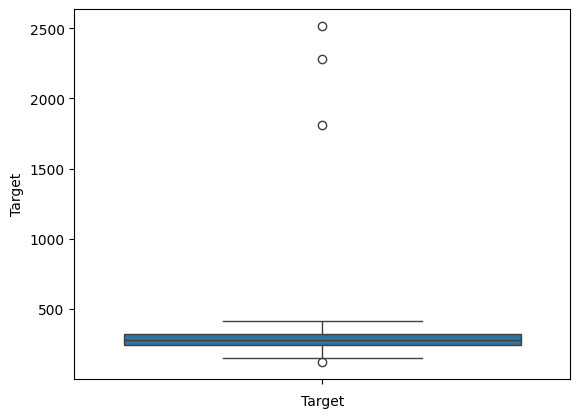

In [ ]:
for col in df.columns:
  if(df[col].dtype!='object'):
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
out_list=['Feature1','Target']
for col in out_list:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR= Q3 -Q1

  LB=Q1-1.5*(IQR)
  UB=Q3+1.5*(IQR)

  df=df[(df[col]>=LB) & (df[col]<=UB)]

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col])
    for code, category in enumerate(le.classes_):
      print(f"{category}-> {code}")
    print()

A-> 0
B-> 1
C-> 2
N-> 3

Alice-> 0
Bob-> 1
Charlie-> 2
David-> 3



In [ ]:
df

,Feature1,Feature2,Feature3,Category,Name,Target
0,54.967142,72.642384,62,0,0,371.099650
1,48.617357,64.446117,63,1,2,299.184743
2,56.476885,61.820944,25,2,1,319.605931
3,65.230299,62.149045,56,2,0,348.440917
4,47.658466,41.569469,33,2,1,201.644393
...,...,...,...,...,...,...
195,53.853174,27.129075,16,2,0,174.938593
196,41.161426,27.051575,8,2,3,184.883015
197,51.537251,58.952618,4,0,3,308.406474
198,50.582087,64.762693,4,1,3,265.922229


In [ ]:
x=df.drop('Target',axis=1)
y=df['Target']

In [ ]:
x

,Feature1,Feature2,Feature3,Category,Name
0,54.967142,72.642384,62,0,0
1,48.617357,64.446117,63,1,2
2,56.476885,61.820944,25,2,1
3,65.230299,62.149045,56,2,0
4,47.658466,41.569469,33,2,1
...,...,...,...,...,...
195,53.853174,27.129075,16,2,0
196,41.161426,27.051575,8,2,3
197,51.537251,58.952618,4,0,3
198,50.582087,64.762693,4,1,3


In [ ]:
y

,Target
0,371.099650
1,299.184743
2,319.605931
3,348.440917
4,201.644393
...,...
195,174.938593
196,184.883015
197,308.406474
198,265.922229


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30)

In [ ]:
x_train.shape

(133, 5)

In [ ]:
x_test.shape

(58, 5)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [ ]:
model_answers=model.predict(x_test)
model_answers

array([266.68501491, 331.49611966, 301.85731425, 270.20934781,
       285.14501626, 294.58288278, 316.95616133, 336.85435334,
       276.62541795, 232.81570062, 265.70740376, 279.64864333,
       275.0814739 , 284.14192571, 250.32437765, 325.72778041,
       245.59092241, 249.408331  , 330.80528283, 200.51942613,
       214.578027  , 204.537147  , 271.81087467, 174.67452356,
       355.13385643, 317.37368458, 240.15347283, 262.98972978,
       256.28888648, 264.22872001, 342.34945908, 201.43104422,
       278.44503725, 283.50701267, 213.77229928, 303.57590333,
       331.11895334, 291.85086377, 234.7800786 , 315.1849906 ,
       312.01664542, 298.09900414, 273.7203343 , 270.78416918,
       305.96029665, 203.28262834, 297.10685719, 282.48980751,
       336.73134262, 351.15508541, 319.54056784, 319.70351038,
       349.36919736, 250.74274024, 334.01893721, 254.11177569,
       210.62939207, 249.8727483 ])

In [ ]:
from sklearn.metrics import r2_score
r2_score(model_answers,y_test)*100

56.11715355817613

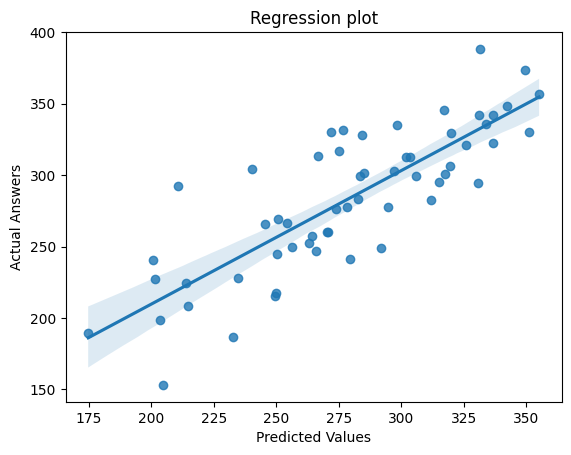

In [ ]:
sns.regplot(x=model_answers,y=y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Answers')
plt.title("Regression plot")
plt.show()

RandomForest Performance:
R² = 0.7478, RMSE = 28.1220, MAE = 22.6893


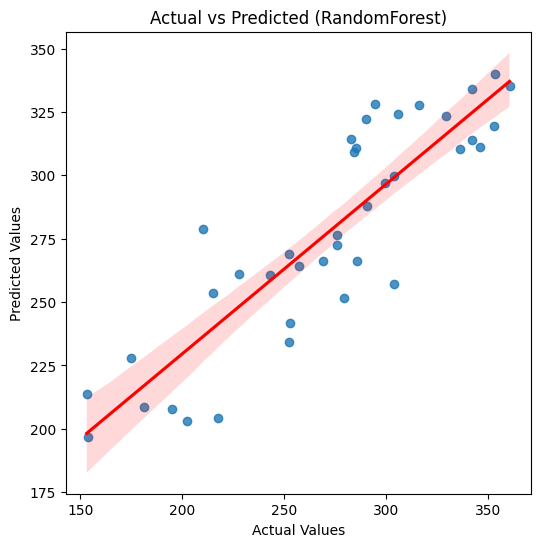

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Change target column here ===
TARGET = "Target"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train RandomForest
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RandomForest Performance:\nR² = {r2:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
sns.regplot(x=y_test, y=y_pred, line_kws={"color":"red"})
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (RandomForest)")
plt.show()


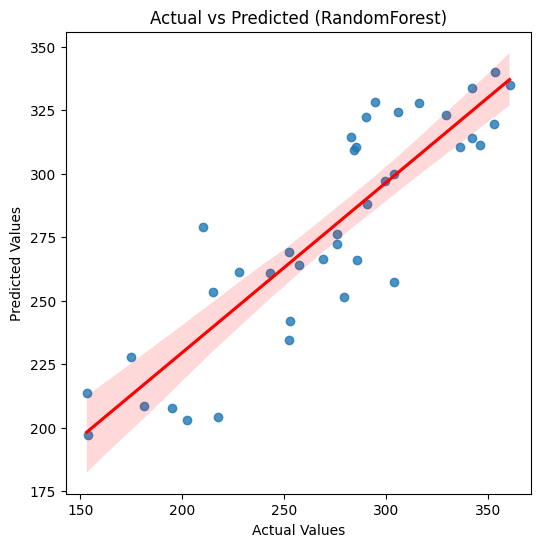

In [ ]:
# Get best model (RandomForest)
best_model_name = "RandomForest"
best_model = models[best_model_name]

# Refit on train and predict
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(6,6))
sns.regplot(x=y_test, y=y_pred_best, line_kws={"color":"red"})
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()
